<a href="https://colab.research.google.com/github/laksamanaap/PCVK_Ganjil_2026/blob/main/P3/PCVK_D1_TugasPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SEL 1: Persiapan dan Mount Drive
from google.colab import drive
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob
import math

drive.mount('/content/drive')

Mounted at /content/drive


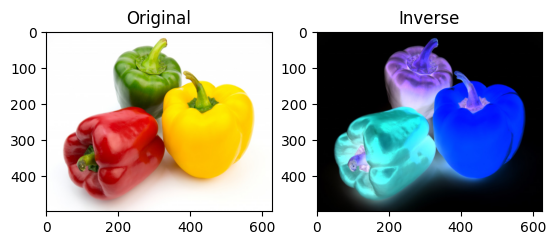

In [ ]:
# SEL 2: Inverse Citra
img = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Implementasi Inverse
img_inverse = 255 - img_rgb

plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(img_inverse), plt.title('Inverse')
plt.show()

Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


/tmp/ipykernel_440/1588429169.py:19: RuntimeWarning: overflow encountered in scalar subtract
  new_val = F * (img_rgb[y,x,c] - 128) + 128 + brightness


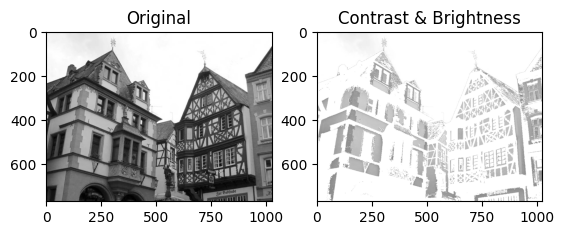

In [ ]:
# SEL 3: Transformasi Contrast
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/old_house.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_contrast = np.zeros(img_rgb.shape, img_rgb.dtype)

# Menghitung factor F
F = (259 * (contrast + 255)) / (255 * (259 - contrast))

for y in range(img_rgb.shape[0]):
    for x in range(img_rgb.shape[1]):
        for c in range(img_rgb.shape[2]):
            # Truncate(F * (Pixel - 128) + 128) + brightness
            new_val = F * (img_rgb[y,x,c] - 128) + 128 + brightness
            img_contrast[y,x,c] = np.clip(new_val, 0, 255)

plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(img_contrast), plt.title('Contrast & Brightness')
plt.show()

Masukkan nilai kecerahan (konstanta c): 10


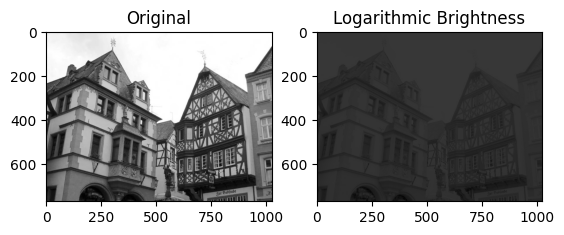

In [ ]:
# SEL 4: Logarithmic Brightness
try:
    c = int(input('Masukkan nilai kecerahan (konstanta c): '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/old_house.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Logarithmic formula: c * log(1 + r)
img_log = c * (np.log(1 + img_rgb.astype(np.float32)))
img_log = np.array(img_log, dtype=np.uint8)

plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(img_log), plt.title('Logarithmic Brightness')
plt.show()

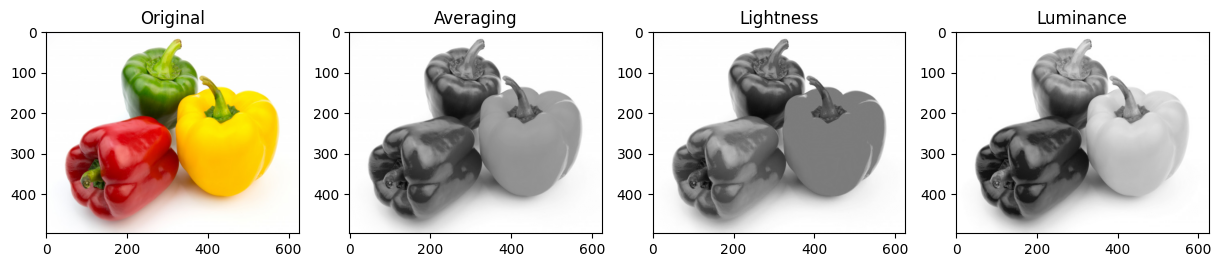

In [ ]:
# SEL 5: Grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

# a. Averaging: (R+G+B)/3
gray_avg = (R/3 + G/3 + B/3).astype(np.uint8)

# b. Lightness: (max(R,G,B) + min(R,G,B)) / 2
gray_lightness = (np.maximum(np.maximum(R, G), B) / 2 + np.minimum(np.minimum(R, G), B) / 2).astype(np.uint8)

# c. Luminance: 0.21R + 0.72G + 0.07B
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(img_rgb), axes[0].set_title('Original')
axes[1].imshow(gray_avg, cmap='gray'), axes[1].set_title('Averaging')
axes[2].imshow(gray_lightness, cmap='gray'), axes[2].set_title('Lightness')
axes[3].imshow(gray_luminance, cmap='gray'), axes[3].set_title('Luminance')
plt.show()

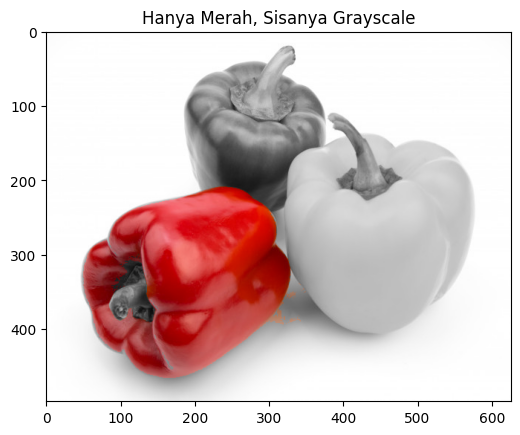

In [ ]:
# SEL 6: Selective Color (Merah)
img = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
hsv_img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Mask untuk warna merah
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv.inRange(hsv_img, lower_red2, upper_red2)
mask = mask1 + mask2

# Gabungkan citra
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_3c = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Gunakan np.where untuk memilih antara pixel merah asli dan pixel grayscale
result = np.where(mask[:, :, None] == 255, img, gray_3c)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

plt.imshow(result_rgb)
plt.title('Hanya Merah, Sisanya Grayscale')
plt.show()

Masukkan nilai Gamma: 10


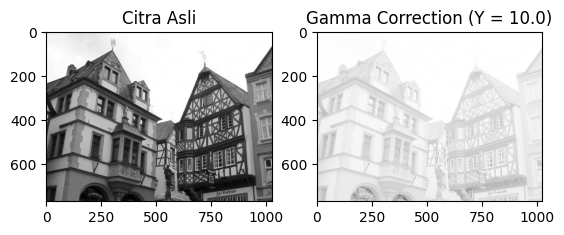

In [ ]:
# SEL 7: Gamma Correction
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/old_house.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Rumus Gamma Correction
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

img_gamma = cv.LUT(img_rgb, table)

plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Citra Asli')
plt.subplot(1, 2, 2), plt.imshow(img_gamma), plt.title(f'Gamma Correction (Y = {gamma})')
plt.show()

Masukkan bit depth tujuan (1-8): 4
Bit depth awal : 8 bit
Bit depth tujuan : 4 bit
Jumlah level : 16


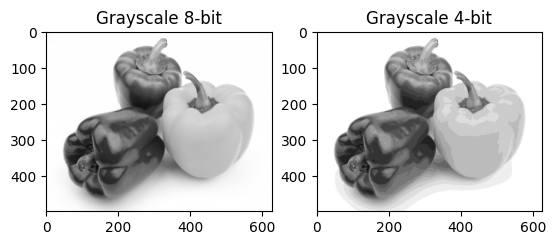

In [ ]:
# SEL 8: Bit Depth
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg', cv.IMREAD_GRAYSCALE)

level = 255.0 / (pow(2, bit_depth) - 1)
depth_image = np.round(img / level) * level
depth_image = np.array(depth_image, dtype=np.uint8)

print(f'Bit depth awal : 8 bit')
print(f'Bit depth tujuan : {bit_depth} bit')
print(f'Jumlah level : {pow(2, bit_depth)}')

plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Grayscale 8-bit')
plt.subplot(1, 2, 2), plt.imshow(depth_image, cmap='gray'), plt.title(f'Grayscale {bit_depth}-bit')
plt.show()

Total gambar noise yang berhasil dibaca: 100 gambar
PSNR untuk 10 citra di-average: 19.73 dB
PSNR untuk 20 citra di-average: 19.84 dB
PSNR untuk 40 citra di-average: 19.89 dB
PSNR untuk 80 citra di-average: 19.92 dB
PSNR untuk 100 citra di-average: 19.92 dB


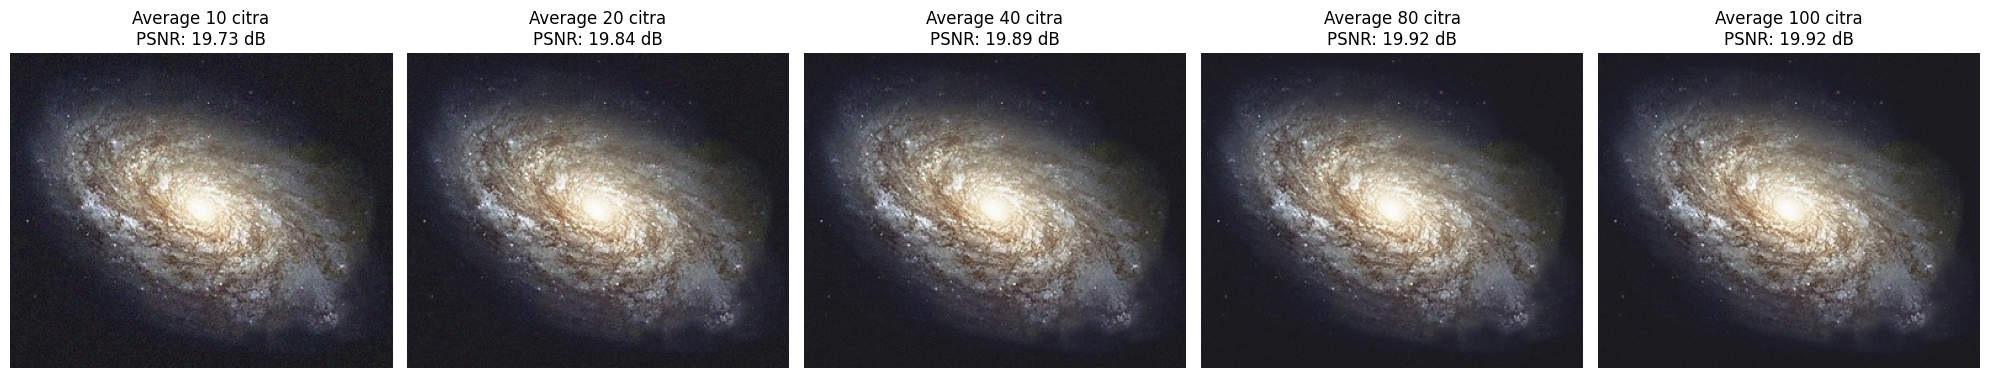

In [ ]:
import cv2 as cv
import numpy as np
import glob
import math
import matplotlib.pyplot as plt

# Menggunakan rumus PSNR sesuai modul
def PSNR(img1, img2):
    # Ubah ke float agar hasil pengurangan tidak error / melampaui batas
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# UBAH INI sesuai dengan folder Google Drive Anda
path_asli = '/content/drive/MyDrive/PCVK/galaxy.jpg'
path_noise = '/content/drive/MyDrive/PCVK/noises/*.jpg' # pakai *.jpg atau *.png sesuai formatnya

# Baca gambar asli dengan mode RGB agar warnanya normal saat ditampilkan
img_asli = cv.imread(path_asli)
img_asli = cv.cvtColor(img_asli, cv.COLOR_BGR2RGB)

# --- 3. BACA SEMUA GAMBAR NOISE ---
cv_img = []
# glob.glob akan mengambil semua file gambar di dalam folder noises
for img_path in glob.glob(path_noise):
    n = cv.imread(img_path)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)

    # Kunci perbaikan error sebelumnya: paksa ukuran noise sama dengan gambar asli
    n = cv.resize(n, (img_asli.shape[1], img_asli.shape[0]))

    cv_img.append(n)

print(f"Total gambar noise yang berhasil dibaca: {len(cv_img)} gambar")

# --- 4. PROSES AVERAGE DENOISING & TAMPILKAN HASIL ---
jumlah_citra = [10, 20, 40, 80, 100]

# Siapkan kanvas matplotlib untuk menampilkan 5 gambar berjajar (1 baris, 5 kolom)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Looping untuk setiap skenario jumlah gambar
for idx, jml in enumerate(jumlah_citra):
    # Jika gambar noise di Drive Anda kurang dari angka yang diminta, kita hentikan agar tidak error
    if len(cv_img) < jml:
        print(f"Melewati {jml} citra karena gambar noise tidak cukup.")
        continue

    # Buat kanvas kosong berwarna hitam (nol) dengan ukuran sama seperti gambar asli
    avg_img = np.zeros(img_asli.shape, np.float32)

    # Tambahkan (tumpuk) gambar noise satu per satu sebanyak 'jml'
    for i in range(jml):
        avg_img += cv_img[i]

    # Hitung rata-rata: Bagi hasil tumpukan dengan jumlah gambar, lalu ubah kembali formatnya ke uint8
    avg_img = (avg_img / jml).astype(np.uint8)

    # Hitung nilai PSNR dengan membandingkan gambar hasil rata-rata vs gambar asli
    psnr_val = PSNR(img_asli, avg_img)
    print(f'PSNR untuk {jml} citra di-average: {psnr_val:.2f} dB')

    # Tampilkan gambar di atas kanvas yang sudah kita siapkan
    axes[idx].imshow(avg_img)
    axes[idx].set_title(f'Average {jml} citra\nPSNR: {psnr_val:.2f} dB')
    axes[idx].axis('off') # Hilangkan angka penggaris di pinggir gambar

# Tampilkan semua gambar ke layar
plt.tight_layout()
plt.show()

Peningkatan jumlah citra tidak selalu menghasilkan peningkatan PSNR yang signifikan. Pada awalnya, seperti dari 10 ke 20 citra, peningkatan kualitas cukup besar. Namun, semakin banyak citra yang digunakan, peningkatan PSNR semakin kecil.

Peningkatan mulai kurang signifikan pada kisaran 40–80 citra, tergantung tingkat noise awal. Penambahan dari 80 ke 100 citra umumnya hanya memberikan peningkatan sekitar 1 dB atau kurang.

**Kesimpulan:** *Average Denoising* efektif mengurangi noise acak seperti *Gaussian noise*. Semakin banyak citra yang dirata-ratakan, semakin tinggi PSNR, tetapi setelah jumlah tertentu peningkatannya semakin kecil sehingga tidak sebanding dengan tambahan beban komputasi.

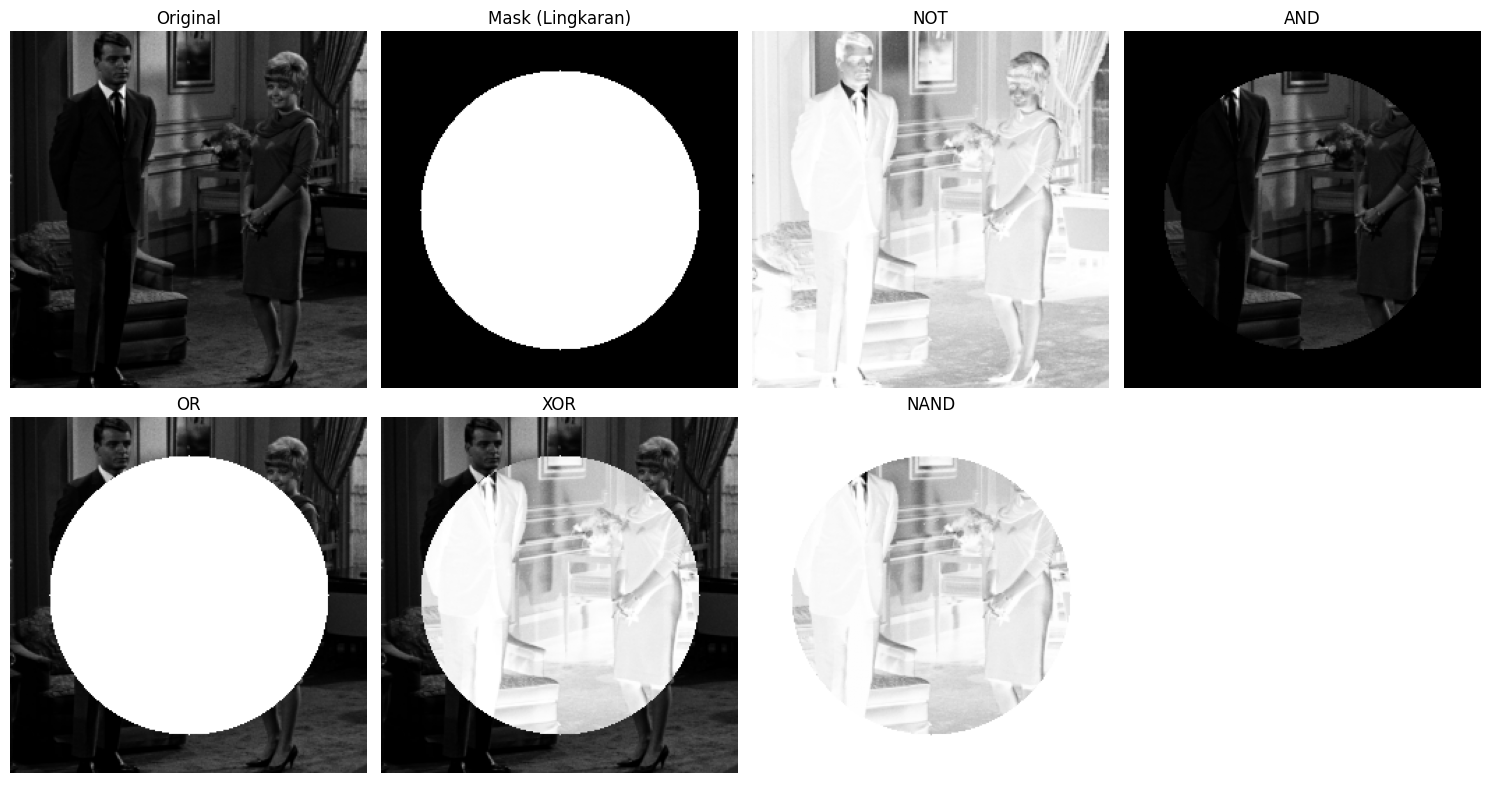

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# SEL 10: Image Masking
img1 = cv.imread('/content/drive/MyDrive/PCVK/couple.tiff', cv.IMREAD_GRAYSCALE)

# Buat citra mask buatan (lingkaran putih di background hitam)
mask = np.zeros(img1.shape, dtype=np.uint8)
cv.circle(mask, (img1.shape[1]//2, img1.shape[0]//2), 100, 255, -1)

# Operasi Logika
op_not = cv.bitwise_not(img1)
op_and = cv.bitwise_and(img1, mask)
op_or = cv.bitwise_or(img1, mask)
op_xor = cv.bitwise_xor(img1, mask)
op_nand = cv.bitwise_not(op_and)

# PROSES MENAMPILKAN SEMUA GAMBAR (PLOTTING)

# Siapkan kanvas 2 baris dan 4 kolom (ukuran 15x8)
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

# Simpan semua gambar dan judulnya di dalam list untuk mempermudah pemanggilan
images = [img1, mask, op_not, op_and, op_or, op_xor, op_nand]
titles = ['Original', 'Mask (Lingkaran)', 'NOT', 'AND', 'OR', 'XOR', 'NAND']

# Tampilkan satu per satu menggunakan perulangan (looping)
for i in range(len(images)):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(images[i], cmap='gray')
    axes[row, col].set_title(titles[i])
    axes[row, col].axis('off') # Sembunyikan garis penggaris

# Matikan kotak terakhir (baris ke-2, kolom ke-4) karena hanya ada 7 gambar
axes[1, 3].axis('off')

# Tampilkan ke layar dengan layout yang rapi
plt.tight_layout()
plt.show()

Pada praktikum ini, citra asli dibandingkan dengan masking berupa latar hitam (0) dan dua lingkaran putih (255) menggunakan beberapa operasi logika.

* **NOT (Komplemen):** Membalik nilai piksel citra sehingga menghasilkan citra negatif, yaitu `255 - nilai piksel`.
* **OR:** Area lingkaran menjadi putih, sedangkan area di luar lingkaran tetap mengikuti citra asli. Hal ini karena OR dengan 255 menghasilkan 255, sedangkan OR dengan 0 mempertahankan nilai asli.
* **AND:** Area di dalam lingkaran mempertahankan citra asli, sementara area di luar menjadi hitam. AND dengan 255 mempertahankan nilai piksel, sedangkan AND dengan 0 menghasilkan 0.
* **NAND:** Merupakan kebalikan dari operasi AND. Area di luar lingkaran menjadi putih, sedangkan area di dalam menjadi negatif.
* **XOR:** Area di luar lingkaran tetap seperti citra asli, sedangkan area di dalam menjadi negatif. XOR dengan 0 mempertahankan nilai piksel, sedangkan XOR dengan 255 membalik nilainya.

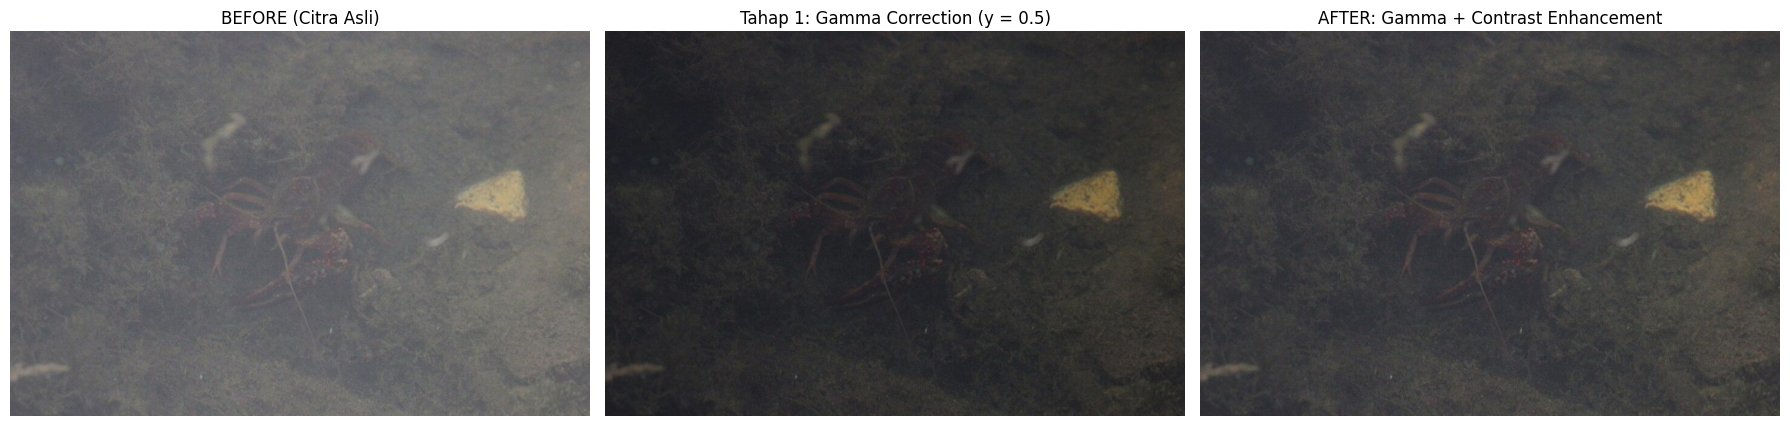

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. BACA GAMBAR
# Sesuaikan path ini dengan lokasi file crayfish.jpg di Drive Anda
path_crayfish = '/content/drive/MyDrive/PCVK/crayfish.jpg'
img_asli = cv.imread(path_crayfish)

if img_asli is None:
    print(f"Error: Gambar tidak ditemukan di {path_crayfish}")
else:
    # Convert BGR (OpenCV) ke RGB (Matplotlib)
    img_asli = cv.cvtColor(img_asli, cv.COLOR_BGR2RGB)

    # 2. METODE 1: GAMMA CORRECTION (Parameter: Gamma = 0.5)
    gamma = 0.5
    inv_gamma = 1.0 / gamma
    # Membuat Look-Up Table (LUT) untuk mempercepat komputasi Gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv.LUT(img_asli, table)

    # 3. METODE 2: CONTRAST & BRIGHTNESS ENHANCEMENT (Parameter: Alpha/Contrast = 1.2, Beta/Brightness = 10)
    alpha = 1.2 # Kontras
    beta = 10   # Linear Brightness
    # cv.convertScaleAbs mengkalkulasi: saturating_cast(Pixel * alpha + beta)
    img_final = cv.convertScaleAbs(img_gamma, alpha=alpha, beta=beta)

    # 4. TAMPILKAN BEFORE - AFTER
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(img_asli)
    axes[0].set_title('BEFORE (Citra Asli)')
    axes[0].axis('off')

    axes[1].imshow(img_gamma)
    axes[1].set_title('Tahap 1: Gamma Correction (y = 0.5)')
    axes[1].axis('off')

    axes[2].imshow(img_final)
    axes[2].set_title('AFTER: Gamma + Contrast Enhancement')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

### Metode yang Dipilih

Metode yang digunakan adalah kombinasi Gamma Correction dan Contrast Transformation. Gamma Correction dipilih untuk mencerahkan citra underexposed secara non-linear sehingga detail pada area gelap dapat terlihat lebih jelas tanpa membuat area terang menjadi terlalu silau. Selanjutnya, Contrast Transformation digunakan untuk meningkatkan ketegasan warna dan memperjelas perbedaan antara objek crayfish dengan latar belakang.

### Parameter yang Digunakan

Parameter terbaik yang digunakan adalah **Gamma (γ) = 0,5**, **Contrast = 1,2**, dan **Brightness = 10**. Nilai gamma di bawah 1 membantu mencerahkan piksel gelap, sedangkan peningkatan kontras dan brightness membuat objek terlihat lebih jelas.
